<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/05.Chapter5%3AMatrices_pt1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5: Matrices, Part 1
## *Practical Linear Algebra for Data Science* — Mike X Cohen

A matrix is a vector taken to the next level. Where a vector is a single column (or row) of numbers, a matrix is a rectangular grid -- an organised collection of numbers that can represent datasets, transformations, systems of equations, images, and much more. This chapter is the first of a three-chapter series on matrices, covering creation, special types, arithmetic, standard matrix multiplication, transpose, and symmetric matrices.

**What we will cover:**

1. Creating and visualising matrices in NumPy
2. Special matrices -- diagonal, triangular, identity, zeros, symmetric
3. Matrix arithmetic -- addition, scalar multiplication, Hadamard multiplication, shifting
4. Standard matrix multiplication -- the row-column dot product rule
5. Matrix-vector multiplication -- linear weighted combinations and geometric transforms
6. Transpose -- LIVE EVIL rule, creating symmetric matrices via $\mathbf{A}^T\mathbf{A}$

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (7, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})

np.random.seed(42)
print('NumPy version:', np.__version__)
print('Setup complete.')

NumPy version: 2.0.2
Setup complete.


Environment ready.

## 1. Creating and Visualising Matrices in NumPy

A **matrix** is a rectangular array of numbers, denoted by bold-faced capital letters ($\mathbf{A}$, $\mathbf{M}$, $\mathbf{X}$). The size is written as $M \times N$ (rows $\times$ columns), so a matrix with 3 rows and 5 columns is in $\mathbb{R}^{3 \times 5}$.

$$
\mathbf{A} = \begin{bmatrix}
a_{1,1} & a_{1,2} & \cdots & a_{1,N} \\
a_{2,1} & a_{2,2} & \cdots & a_{2,N} \\
\vdots  & \vdots  & \ddots & \vdots  \\
a_{M,1} & a_{M,2} & \cdots & a_{M,N}
\end{bmatrix}
\in \mathbb{R}^{M \times N}
$$

Element $a_{i,j}$ sits at row $i$, column $j$ (1-indexed in math, 0-indexed in Python: `A[i-1, j-1]`).

Depending on the context, a matrix can be conceptualised as:

- A set of **column vectors** stacked side by side (e.g., features in a data table)
- A set of **row vectors** layered on top of each other (e.g., multi-sensor time series)
- An ordered grid of **individual elements** (e.g., pixel intensities in an image)

In [2]:
# Creating matrices
A_manual = np.array([
    [1, 3, 5, 7, 9],
    [0, 2, 4, 6, 8],
    [1, 4, 7, 8, 9]
])

print(f'Matrix A (manual):\n{A_manual}')
print(f'Shape: {A_manual.shape} ({A_manual.shape[0]} rows x {A_manual.shape[1]} columns)')
print(f'Element a_{{3,4}} (math indexing) = A[2,3] (Python) = {A_manual[2, 3]}')

Matrix A (manual):
[[1 3 5 7 9]
 [0 2 4 6 8]
 [1 4 7 8 9]]
Shape: (3, 5) (3 rows x 5 columns)
Element a_{3,4} (math indexing) = A[2,3] (Python) = 8


The matrix is $3 \times 5$ with element $a_{3,4} = 8$. The indexing offset between math (1-based) and Python (0-based) is a constant source of bugs -- always double-check when translating formulas into code.

### 1.1 Visualising Matrices as Images

For large matrices, numerical printouts are impractical. Instead, we map each element's value to a colour. This is called a **heat map** or **pseudocolour image** -- "pseudo" because the colour mapping is arbitrary.

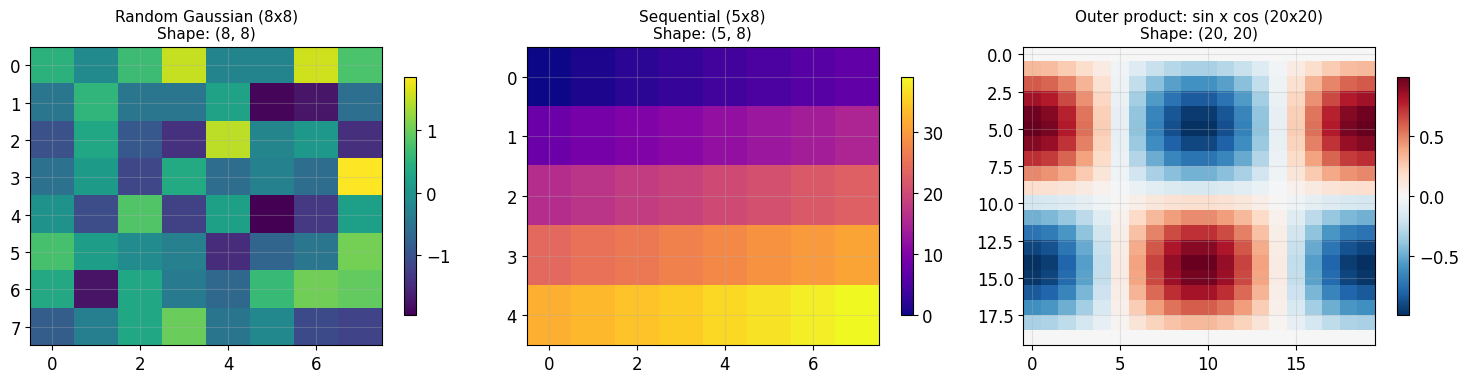

Figure saved.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

np.random.seed(42)
matrices = [
    (np.random.randn(8, 8), 'Random Gaussian (8x8)', 'viridis'),
    (np.arange(40).reshape(5, 8), 'Sequential (5x8)', 'plasma'),
    (np.outer(np.sin(np.linspace(0, 2*np.pi, 20)),
              np.cos(np.linspace(0, 2*np.pi, 20))),
     'Outer product: sin x cos (20x20)', 'RdBu_r'),
]

for ax, (M, title, cmap) in zip(axes, matrices):
    im = ax.imshow(M, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'{title}\nShape: {M.shape}', fontsize=11)

plt.tight_layout()
plt.savefig('fig_matrix_viz.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

Three matrices visualised as images:

- **Left:** An $8 \times 8$ random Gaussian matrix -- no structure, random noise.
- **Centre:** A $5 \times 8$ sequential matrix -- the smooth gradient reveals the monotonic fill pattern.
- **Right:** A $20 \times 20$ outer product of sine and cosine -- the distinctive checkerboard structure is characteristic of **rank-1** matrices (every row is a scalar multiple of every other row), a concept formalised in Chapter 6.

**Production insight:** Matrix visualisation is a powerful diagnostic. A covariance matrix should look like a smooth heat map with the largest values on the diagonal. A data matrix with unexpected block structure may indicate batch effects. An image matrix with sharp edges may need different preprocessing from one with smooth gradients.

### 1.2 Indexing and Slicing

In [4]:
# Create a 6x10 matrix and extract a submatrix
A = np.arange(60).reshape(6, 10)
print(f'Full matrix A (6x10):')
print(A)

# Extract rows 2-4 (indices 1:4), columns 1-5 (indices 0:5)
sub = A[1:4:1, 0:5:1]
print(f'\nSubmatrix A[1:4, 0:5] (rows 2-4, cols 1-5 in math):')
print(sub)
print(f'Shape: {sub.shape}')

Full matrix A (6x10):
[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]]

Submatrix A[1:4, 0:5] (rows 2-4, cols 1-5 in math):
[[10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]]
Shape: (3, 5)


The slice `A[1:4, 0:5]` extracts rows at indices $1, 2, 3$ and columns at indices $0, 1, 2, 3, 4$, producing a $3 \times 5$ submatrix. In math notation, this corresponds to rows $2$--$4$ and columns $1$--$5$.

Slicing is used extensively in data science: selecting subsets of features, extracting train/test splits by row, and windowing time-series data. The `start:stop:step` syntax is identical for 1D arrays, 2D matrices, and higher-dimensional tensors.

## 2. Special Matrices

Matrices come in families defined by structural properties. Recognising these families is essential because many algorithms require specific matrix types (e.g., symmetric positive-definite for Cholesky decomposition) or produce specific types as output (e.g., orthogonal matrices from QR decomposition).

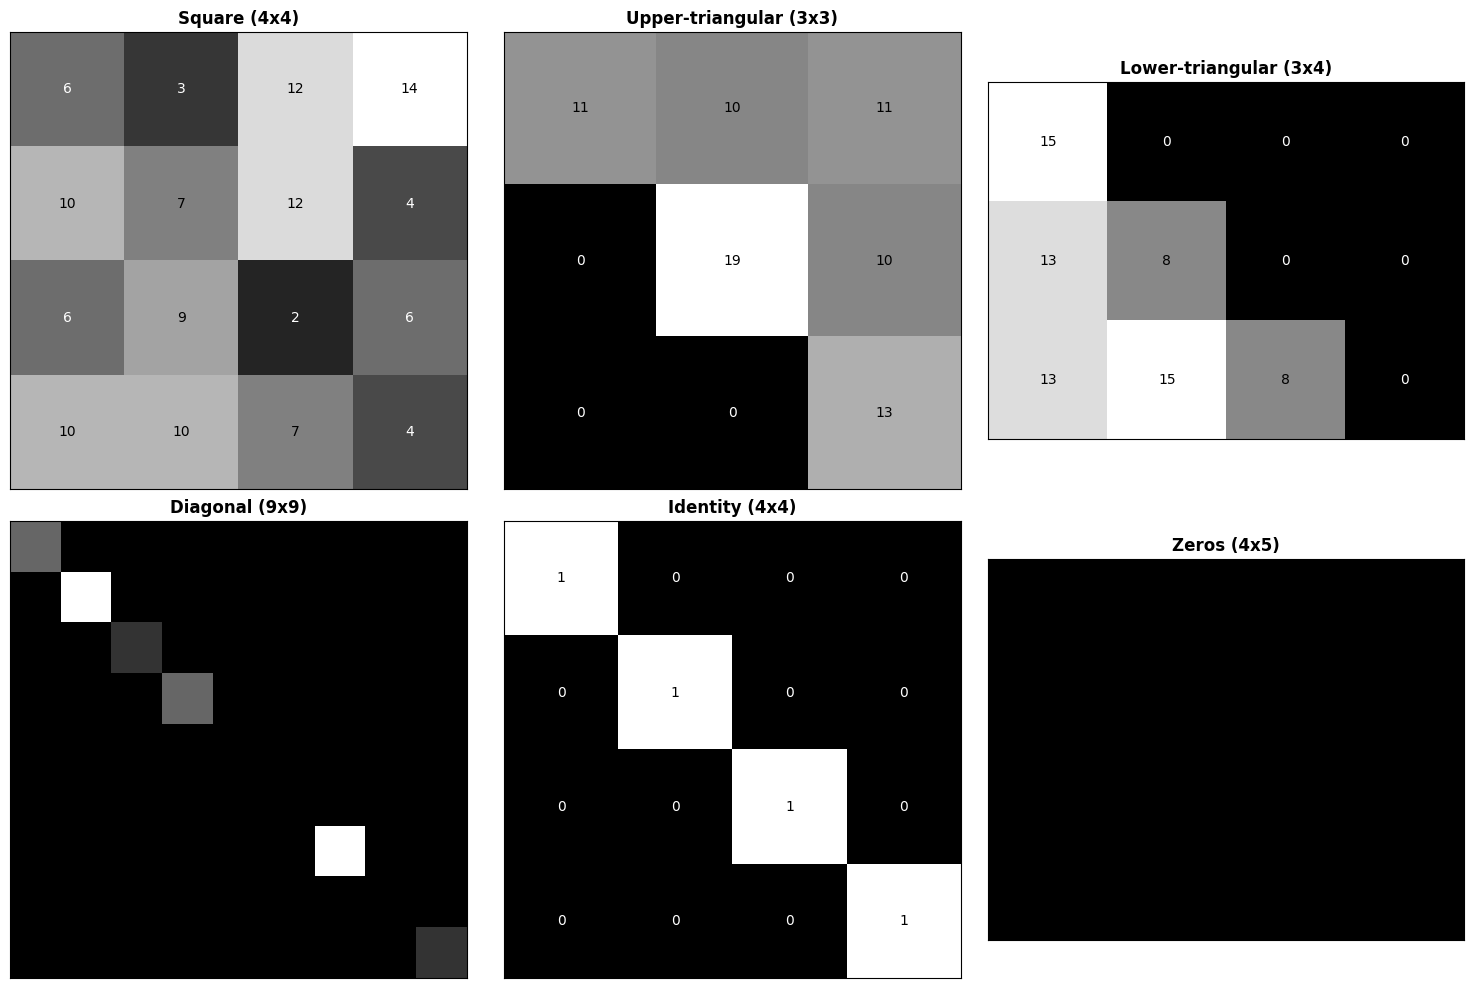

Figure saved.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

np.random.seed(42)

# 1. Square random
sq = np.random.randint(0, 16, (4, 4))

# 2. Upper triangular
upper = np.array([[11, 10, 11], [0, 19, 10], [0, 0, 13]])

# 3. Lower triangular
lower = np.array([[15, 0, 0, 0], [13, 8, 0, 0], [13, 15, 8, 0]])

# 4. Diagonal
diag = np.diag([2, 5, 1, 2, 0, 0, 5, 0, 1])

# 5. Identity
ident = np.eye(4)

# 6. Zeros
zeros = np.zeros((4, 5))

mats = [
    (sq, 'Square (4x4)'),
    (upper, 'Upper-triangular (3x3)'),
    (lower, 'Lower-triangular (3x4)'),
    (diag, 'Diagonal (9x9)'),
    (ident, 'Identity (4x4)'),
    (zeros, 'Zeros (4x5)'),
]

for ax, (M, title) in zip(axes.flat, mats):
    im = ax.imshow(M, cmap='gray', vmin=0, vmax=max(np.max(M), 1))
    ax.set_title(title, fontsize=12, fontweight='bold')
    # Annotate values
    for (r, c), val in np.ndenumerate(M):
        if M.shape[0] <= 5 and M.shape[1] <= 5:
            color = 'white' if val < np.max(M)/2 else 'black'
            ax.text(c, r, f'{int(val)}', ha='center', va='center',
                    fontsize=10, color=color)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('fig_special_matrices.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

Six families of special matrices, following the textbook's Figure 5-2:

| Type | Key property | NumPy creation |
|------|-------------|----------------|
| **Square** | $M = N$ (rows $=$ columns) | `np.random.randn(N, N)` |
| **Upper-triangular** | Zeros below the diagonal | `np.triu(A)` |
| **Lower-triangular** | Zeros above the diagonal | `np.tril(A)` |
| **Diagonal** | Nonzero only on the main diagonal | `np.diag(v)` |
| **Identity** ($\mathbf{I}$) | Diagonal matrix with all $1$s; $\mathbf{A}\mathbf{I} = \mathbf{I}\mathbf{A} = \mathbf{A}$ | `np.eye(N)` |
| **Zeros** ($\mathbf{0}$) | All entries are zero | `np.zeros((M, N))` |

The **identity matrix** deserves special emphasis: it is the multiplicative identity for matrices, analogous to the number $1$ for scalars. Any matrix (or vector) multiplied by $\mathbf{I}$ is unchanged: $\mathbf{A}\mathbf{I} = \mathbf{I}\mathbf{A} = \mathbf{A}$. This property makes $\mathbf{I}$ central to solving linear systems, computing inverses, and understanding eigenvalues.

### 2.1 Creating Special Matrices in Code

In [6]:
# Random matrix
Mrows, Ncols = 4, 6
A_rand = np.random.randn(Mrows, Ncols)
print(f'Random Gaussian ({Mrows}x{Ncols}):')
print(np.round(A_rand, 2))

# Diagonal: vector -> matrix, and matrix -> vector
v = np.array([2, 5, 1, 2])
D = np.diag(v)
print(f'\nnp.diag(vector) creates matrix:')
print(D)

diag_back = np.diag(D)
print(f'\nnp.diag(matrix) extracts diagonal: {diag_back}')

# Triangular extraction
S = np.arange(1, 17).reshape(4, 4)
print(f'\nOriginal matrix:\n{S}')
print(f'Upper triangle:\n{np.triu(S)}')
print(f'Lower triangle:\n{np.tril(S)}')

# Identity
I4 = np.eye(4)
print(f'\nIdentity I_4:\n{I4.astype(int)}')

Random Gaussian (4x6):
[[ 1.58  0.77 -0.47  0.54 -0.46 -0.47]
 [ 0.24 -1.91 -1.72 -0.56 -1.01  0.31]
 [-0.91 -1.41  1.47 -0.23  0.07 -1.42]
 [-0.54  0.11 -1.15  0.38 -0.6  -0.29]]

np.diag(vector) creates matrix:
[[2 0 0 0]
 [0 5 0 0]
 [0 0 1 0]
 [0 0 0 2]]

np.diag(matrix) extracts diagonal: [2 5 1 2]

Original matrix:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
Upper triangle:
[[ 1  2  3  4]
 [ 0  6  7  8]
 [ 0  0 11 12]
 [ 0  0  0 16]]
Lower triangle:
[[ 1  0  0  0]
 [ 5  6  0  0]
 [ 9 10 11  0]
 [13 14 15 16]]

Identity I_4:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]


Key observations:

The `np.diag()` function is **overloaded** -- it behaves differently depending on the input. Given a 1D vector, it creates a diagonal matrix; given a 2D matrix, it extracts the diagonal as a vector. This dual behaviour is convenient but requires attention to input shapes.

The triangular extraction functions `np.triu()` and `np.tril()` zero out the lower or upper portion of a matrix, respectively. Note that the original matrix is unchanged -- these functions return a *copy*.

**Cross-chapter preview:** Triangular matrices appear in **LU decomposition** (Chapter 6) and **Cholesky decomposition** (Chapter 9). Diagonal matrices are central to the **singular value decomposition** (Chapter 14), where $\boldsymbol{\Sigma}$ is a diagonal matrix of singular values.

## 3. Matrix Arithmetic: Addition, Scalar Multiplication, Hadamard Multiplication

These are the "intuitive" operations -- they all work **element-wise**, exactly as they do for vectors.

### 3.1 Addition and Subtraction

Add corresponding elements. Both matrices must have the **same size**:

$$
(\mathbf{A} + \mathbf{B})_{i,j} = a_{i,j} + b_{i,j}
$$

In [7]:
A = np.array([[2, 3, 4], [1, 2, 4]])
B = np.array([[0, 3, 1], [-1, -4, 2]])

print(f'A =\n{A}')
print(f'\nB =\n{B}')
print(f'\nA + B =\n{A + B}')
print(f'\nA - B =\n{A - B}')

# Size mismatch
C = np.array([[1, 2], [3, 4], [5, 6]])
try:
    A + C
except ValueError as e:
    print(f'\nA ({A.shape}) + C ({C.shape}): {e}')

A =
[[2 3 4]
 [1 2 4]]

B =
[[ 0  3  1]
 [-1 -4  2]]

A + B =
[[ 2  6  5]
 [ 0 -2  6]]

A - B =
[[2 0 3]
 [2 6 2]]

A ((2, 3)) + C ((3, 2)): operands could not be broadcast together with shapes (2,3) (3,2) 


Element-wise addition:

$$
\begin{bmatrix} 2 & 3 & 4 \\ 1 & 2 & 4 \end{bmatrix}
+
\begin{bmatrix} 0 & 3 & 1 \\ -1 & -4 & 2 \end{bmatrix}
=
\begin{bmatrix} 2 & 6 & 5 \\ 0 & -2 & 6 \end{bmatrix}
$$

Attempting to add a $(2 \times 3)$ matrix to a $(3 \times 2)$ matrix raises a `ValueError` -- the shapes must match exactly for element-wise operations.

### 3.2 "Shifting" a Matrix

Adding a scalar to a *square* matrix in a linear-algebra-consistent way means adding $\lambda$ only to the **diagonal** elements, via the identity matrix:

$$
\mathbf{A} + \lambda \mathbf{I}
$$

This is called **shifting** the matrix. It leaves all off-diagonal elements unchanged. Shifting has two critical applications:

1. **Finding eigenvalues:** The eigenvalue equation is $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$, which rearranges to $(\mathbf{A} - \lambda\mathbf{I})\mathbf{v} = \mathbf{0}$ (Chapter 13).
2. **Regularisation:** Adding $\lambda\mathbf{I}$ to $\mathbf{X}^T\mathbf{X}$ ensures invertibility in **ridge regression** (Chapters 11--12).

In [8]:
A = np.array([[4, 5, 1], [0, 1, 11], [4, 9, 7]])
s = 6

# NOT shifting -- adds s to every element (broadcasting)
broadcast_add = A + s

# Proper shifting -- adds s only to diagonal
shifted = A + s * np.eye(len(A))

print(f'Original A:')
print(A)
print(f'\nA + {s} (broadcasting, NOT shifting):')
print(broadcast_add)
print(f'\nA + {s}*I (proper shifting):')
print(shifted.astype(int))
print(f'\nOnly diagonal changed: off-diag preserved? '
      f'{np.array_equal(A[~np.eye(3, dtype=bool)], shifted[~np.eye(3, dtype=bool)].astype(int))}')

Original A:
[[ 4  5  1]
 [ 0  1 11]
 [ 4  9  7]]

A + 6 (broadcasting, NOT shifting):
[[10 11  7]
 [ 6  7 17]
 [10 15 13]]

A + 6*I (proper shifting):
[[10  5  1]
 [ 0  7 11]
 [ 4  9 13]]

Only diagonal changed: off-diag preserved? True


The contrast is clear:

- `A + 6` (broadcasting) adds $6$ to *every* element -- convenient in Python but not a formal linear algebra operation.
- `A + 6*I` (shifting) adds $6$ only to the **diagonal** elements $(4 \to 10, 1 \to 7, 7 \to 13)$, leaving off-diagonal entries untouched.

$$
\begin{bmatrix} 4 & 5 & 1 \\ 0 & 1 & 11 \\ 4 & 9 & 7 \end{bmatrix}
+ 6
\begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}
=
\begin{bmatrix} 10 & 5 & 1 \\ 0 & 7 & 11 \\ 4 & 9 & 13 \end{bmatrix}
$$

In practice, the shift amount $\lambda$ is typically a small fraction of the matrix norm or average eigenvalue -- just enough to ensure numerical stability without distorting the matrix's information content.

### 3.3 Scalar Multiplication and Hadamard Multiplication

Both operate element-wise. **Scalar multiplication** scales every entry by the same factor. **Hadamard multiplication** $\odot$ multiplies corresponding entries from two same-size matrices:

$$
\gamma \mathbf{A}: \;(\gamma\mathbf{A})_{i,j} = \gamma \cdot a_{i,j}
\qquad\qquad
\mathbf{A} \odot \mathbf{B}: \;(\mathbf{A} \odot \mathbf{B})_{i,j} = a_{i,j} \cdot b_{i,j}
$$

In [9]:
A = np.array([[2, 3], [4, 5]])
B = np.array([[10, 20], [30, 40]])
gamma = 3

print(f'A = \n{A}')
print(f'B = \n{B}')
print(f'\nScalar multiplication: {gamma} * A =')
print(gamma * A)
print(f'\nHadamard multiplication: A * B (element-wise) =')
print(A * B)

# CRITICAL: difference from matrix multiplication
print(f'\nStandard matrix multiplication: A @ B =')
print(A @ B)
print(f'\nA*B != A@B:  {not np.array_equal(A*B, A@B)}')

A = 
[[2 3]
 [4 5]]
B = 
[[10 20]
 [30 40]]

Scalar multiplication: 3 * A =
[[ 6  9]
 [12 15]]

Hadamard multiplication: A * B (element-wise) =
[[ 20  60]
 [120 200]]

Standard matrix multiplication: A @ B =
[[110 160]
 [190 280]]

A*B != A@B:  True


The three types of multiplication produce entirely different results:

| Operation | Python syntax | Result |
|-----------|:---:|:---:|
| Scalar | `3 * A` | $\begin{bmatrix} 6 & 9 \\ 12 & 15 \end{bmatrix}$ |
| Hadamard | `A * B` | $\begin{bmatrix} 20 & 60 \\ 120 & 200 \end{bmatrix}$ |
| Standard | `A @ B` | $\begin{bmatrix} 110 & 160 \\ 190 & 280 \end{bmatrix}$ |

**Python syntax trap:** In NumPy, `*` is **Hadamard** (element-wise) and `@` is **standard** matrix multiplication. This is the opposite of MATLAB, where `*` is standard and `.*` is element-wise. If you are transitioning from MATLAB, triple-check every `*` in your code.

## 4. Standard Matrix Multiplication

### 4.1 The Validity Rule

Matrix multiplication $\mathbf{A}\mathbf{B}$ is valid **only** when the number of columns in $\mathbf{A}$ equals the number of rows in $\mathbf{B}$. The result size is determined by the "outer" dimensions:

$$
\underbrace{\mathbf{A}}_{M \times \boxed{N}}
\underbrace{\mathbf{B}}_{\boxed{N} \times K}
=
\underbrace{\mathbf{C}}_{M \times K}
$$

The **inner dimensions** (both $N$) must match; the **outer dimensions** ($M$ and $K$) define the product size. Memorise this rule -- it is used constantly.

In [10]:
# Validity examples
A = np.random.randn(3, 4)  # 3x4
B = np.random.randn(4, 2)  # 4x2
C = np.random.randn(5, 3)  # 5x3

# Valid: (3x4) @ (4x2) = (3x2)
AB = A @ B
print(f'A ({A.shape}) @ B ({B.shape}) = AB ({AB.shape})  -- valid!')

# Valid: (5x3) @ (3x4) = (5x4)
CA = C @ A
print(f'C ({C.shape}) @ A ({A.shape}) = CA ({CA.shape})  -- valid!')

# Invalid: (3x4) @ (5x3) -- inner dims 4 != 5
try:
    A @ C
except ValueError as e:
    print(f'A ({A.shape}) @ C ({C.shape}) -- INVALID: {e}')

# Non-commutativity
P = np.array([[1, 2], [3, 4]])
Q = np.array([[5, 6], [7, 8]])
print(f'\nPQ =\n{P @ Q}')
print(f'QP =\n{Q @ P}')
print(f'PQ == QP? {np.array_equal(P @ Q, Q @ P)}')

A ((3, 4)) @ B ((4, 2)) = AB ((3, 2))  -- valid!
C ((5, 3)) @ A ((3, 4)) = CA ((5, 4))  -- valid!
A ((3, 4)) @ C ((5, 3)) -- INVALID: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 4)

PQ =
[[19 22]
 [43 50]]
QP =
[[23 34]
 [31 46]]
PQ == QP? False


The validity rule works exactly as described:

- $(3 \times \boxed{4}) \times (\boxed{4} \times 2) \to (3 \times 2)$ -- inner dimensions match ($4 = 4$).
- $(5 \times \boxed{3}) \times (\boxed{3} \times 4) \to (5 \times 4)$ -- inner dimensions match ($3 = 3$).
- $(3 \times 4) \times (5 \times 3)$ -- inner dimensions mismatch ($4 \neq 5$), so Python raises a `ValueError`.

Even when both $\mathbf{P}\mathbf{Q}$ and $\mathbf{Q}\mathbf{P}$ are valid (e.g., both square), the results are generally **not equal**. Matrix multiplication is **not commutative**: $\mathbf{A}\mathbf{B} \neq \mathbf{B}\mathbf{A}$ in general. This is a fundamental departure from scalar arithmetic and has major implications for the order of operations in linear algebra.

### 4.2 The Mechanics: Dot Products of Rows and Columns

Element $(i, j)$ of the product $\mathbf{C} = \mathbf{A}\mathbf{B}$ is the **dot product** of the $i$-th row of $\mathbf{A}$ with the $j$-th column of $\mathbf{B}$:

$$
c_{i,j} = \sum_{k=1}^{N} a_{i,k} \, b_{k,j} = \text{row}_i(\mathbf{A})^T \cdot \text{col}_j(\mathbf{B})
$$

The textbook's example:

$$
\begin{bmatrix} 2 & 3 \\ 4 & 5 \end{bmatrix}
\begin{bmatrix} a & b \\ c & d \end{bmatrix}
=
\begin{bmatrix} 2a + 3c & 2b + 3d \\ 4a + 5c & 4b + 5d \end{bmatrix}
$$

In [11]:
# Step-by-step matrix multiplication
A = np.array([[2, 3], [4, 5]])
B = np.array([[1, 7], [3, 2]])

C = A @ B

print(f'A =\n{A}')
print(f'B =\n{B}')
print(f'C = A @ B =\n{C}')

# Verify each element as a dot product
print(f'\nVerification (row.col dot products):')
for i in range(2):
    for j in range(2):
        dp = np.dot(A[i, :], B[:, j])
        print(f'  C[{i},{j}] = row{i}(A) . col{j}(B) = '
              f'{A[i,:]} . {B[:,j]} = {dp}')

A =
[[2 3]
 [4 5]]
B =
[[1 7]
 [3 2]]
C = A @ B =
[[11 20]
 [19 38]]

Verification (row.col dot products):
  C[0,0] = row0(A) . col0(B) = [2 3] . [1 3] = 11
  C[0,1] = row0(A) . col1(B) = [2 3] . [7 2] = 20
  C[1,0] = row1(A) . col0(B) = [4 5] . [1 3] = 19
  C[1,1] = row1(A) . col1(B) = [4 5] . [7 2] = 38


Each element of $\mathbf{C}$ is verified as the dot product of the corresponding row of $\mathbf{A}$ and column of $\mathbf{B}$:

$$
\begin{bmatrix} 2 & 3 \\ 4 & 5 \end{bmatrix}
\begin{bmatrix} 1 & 7 \\ 3 & 2 \end{bmatrix}
=
\begin{bmatrix}
2 \cdot 1 + 3 \cdot 3 & 2 \cdot 7 + 3 \cdot 2 \\
4 \cdot 1 + 5 \cdot 3 & 4 \cdot 7 + 5 \cdot 2
\end{bmatrix}
=
\begin{bmatrix} 11 & 20 \\ 19 & 38 \end{bmatrix}
$$

**Interpretation:** The product matrix $\mathbf{C}$ is an organised collection of **all pairwise linear relationships** between rows of $\mathbf{A}$ and columns of $\mathbf{B}$. This is the computational engine behind covariance matrices ($\mathbf{X}^T\mathbf{X}$), regression ($\mathbf{X}\boldsymbol{\beta}$), and the SVD.

**Computational complexity:** Multiplying an $(M \times N)$ by an $(N \times K)$ matrix requires $M \cdot N \cdot K$ multiplications and approximately the same number of additions, giving $O(M \cdot N \cdot K)$ time complexity. For square matrices, this is $O(N^3)$ -- expensive for large $N$.

## 5. Matrix-Vector Multiplication

Matrix-vector multiplication is simply matrix multiplication where one "matrix" is a vector. Despite being a special case, it deserves attention because of its pervasive applications.

**Orientation rules:**
- Post-multiply by a **column** vector: $\mathbf{A}\mathbf{v}$ (valid if $\mathbf{A}$ is $M \times N$ and $\mathbf{v} \in \mathbb{R}^N$; result is $M \times 1$)
- Pre-multiply by a **row** vector: $\mathbf{v}^T\mathbf{A}$ (valid if $\mathbf{v} \in \mathbb{R}^M$ and $\mathbf{A}$ is $M \times N$; result is $1 \times N$)

### 5.1 Linear Weighted Combinations via Matrix-Vector Multiplication

In Chapter 3, we computed linear weighted combinations by individually scaling and summing vectors. Matrix-vector multiplication is the **compact, scalable** way to do the same thing: pack the vectors as columns of a matrix and the weights into a vector.

In [12]:
# Textbook example: linear weighted combination via Mv
# 4*[3,0,6] + 3*[1,2,5]
M = np.array([[3, 1],
              [0, 2],
              [6, 5]])
v = np.array([4, 3])

result = M @ v

print(f'M (columns are vectors):\n{M}')
print(f'v (weights): {v}')
print(f'\nM @ v = {result}')

# Manual verification
manual = 4 * M[:, 0] + 3 * M[:, 1]
print(f'Manual: 4*col0 + 3*col1 = {manual}')
print(f'Match: {np.array_equal(result, manual)}')

M (columns are vectors):
[[3 1]
 [0 2]
 [6 5]]
v (weights): [4 3]

M @ v = [15  6 39]
Manual: 4*col0 + 3*col1 = [15  6 39]
Match: True


The matrix-vector product $\mathbf{M}\mathbf{v}$ computes exactly the same linear weighted combination as the manual approach:

$$
\begin{bmatrix} 3 & 1 \\ 0 & 2 \\ 6 & 5 \end{bmatrix}
\begin{bmatrix} 4 \\ 3 \end{bmatrix}
= 4 \begin{bmatrix} 3 \\ 0 \\ 6 \end{bmatrix}
+ 3 \begin{bmatrix} 1 \\ 2 \\ 5 \end{bmatrix}
= \begin{bmatrix} 15 \\ 6 \\ 39 \end{bmatrix}
$$

**Key insight:** Each element of the vector $\mathbf{v}$ scalar-multiplies the corresponding **column** of $\mathbf{M}$, and the weighted columns are summed. This "column perspective" of matrix-vector multiplication is fundamental -- it tells us that $\mathbf{M}\mathbf{v}$ is always a linear combination of the columns of $\mathbf{M}$.

**Applications:**
- **Regression:** $\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\beta}$ -- predictions are a linear combination of feature columns weighted by coefficients.
- **PCA:** $\mathbf{Y}^T\mathbf{Y}\mathbf{v}$ -- the feature-importance eigenvector.
- **Spatial filtering:** $\mathbf{w}^T\mathbf{S}$ -- a single component from multichannel data.

### 5.2 Geometric Transformations

When we interpret vectors geometrically, matrix-vector multiplication becomes a **transformation** that can rotate and scale the vector. A scalar can only scale; a matrix can rotate *and* scale.

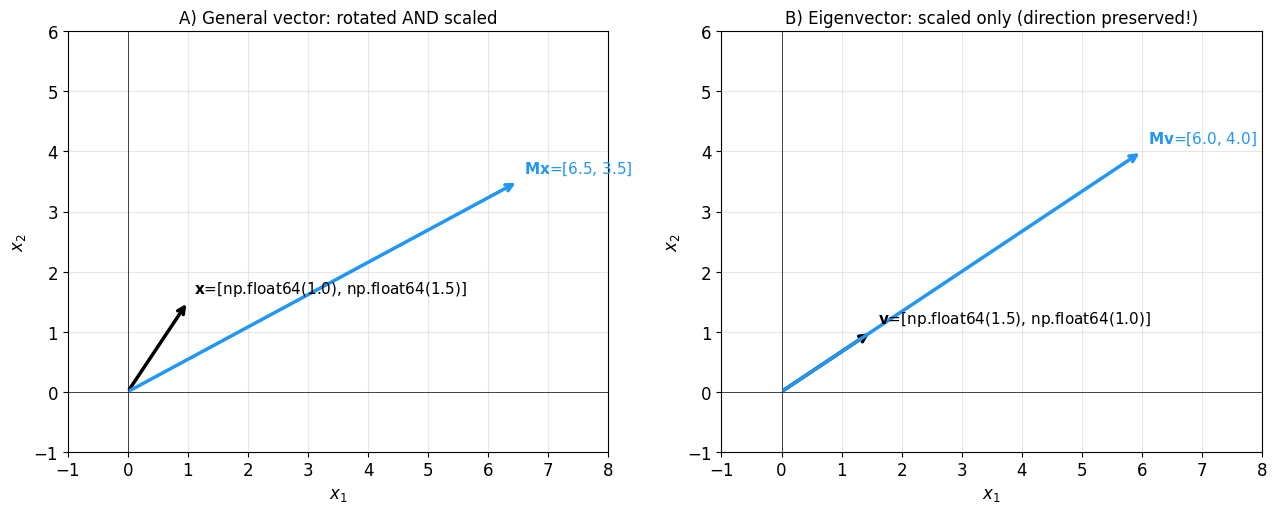

x  = [1.  1.5]  ->  Mx  = [6.5 3.5]  (rotated + scaled)
v  = [1.5 1. ]  ->  Mv  = [6. 4.]  (scaled only!)

Ratio Mv / v: [4. 4.]  (constant = eigenvalue!)


In [13]:
M = np.array([[2, 3], [2, 1]])
x = np.array([1, 1.5])
v = np.array([1.5, 1])  # this one is special!

Mx = M @ x
Mv = M @ v

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, vec, Mvec, label in zip(axes, [x, v], [Mx, Mv], ['x', 'v']):
    ax.annotate('', xy=vec, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='k', lw=2.5))
    ax.annotate('', xy=Mvec, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#2196F3', lw=2.5))
    ax.text(vec[0]+0.1, vec[1]+0.15, f'$\mathbf{{{label}}}$={list(vec)}',
            fontsize=11)
    ax.text(Mvec[0]+0.1, Mvec[1]+0.15,
            f'$\mathbf{{M{label}}}$=[{Mvec[0]:.1f}, {Mvec[1]:.1f}]',
            fontsize=11, color='#2196F3')
    ax.set_xlim(-1, 8)
    ax.set_ylim(-1, 6)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

axes[0].set_title('A) General vector: rotated AND scaled', fontsize=12)
axes[1].set_title('B) Eigenvector: scaled only (direction preserved!)', fontsize=12)

plt.tight_layout()
plt.savefig('fig_mat_vec_geom.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'x  = {x}  ->  Mx  = {Mx}  (rotated + scaled)')
print(f'v  = {v}  ->  Mv  = {Mv}  (scaled only!)')
print(f'\nRatio Mv / v: {Mv / v}  (constant = eigenvalue!)')

Panel A shows a general vector $\mathbf{x} = [1, 1.5]^T$: the matrix $\mathbf{M}$ both **rotates** and **scales** it. The output $\mathbf{Mx} = [6.5, 3.5]^T$ points in a different direction from $\mathbf{x}$.

Panel B shows something remarkable: for $\mathbf{v} = [1.5, 1]^T$, the matrix $\mathbf{M}$ only **scales** $\mathbf{v}$ without rotating it. The output $\mathbf{Mv}$ has the exact same direction as $\mathbf{v}$, just stretched. The ratio $\mathbf{Mv} / \mathbf{v}$ is a constant across all elements -- this constant is the **eigenvalue**, and $\mathbf{v}$ is an **eigenvector** of $\mathbf{M}$.

$$
\mathbf{M}\mathbf{v} = \lambda \mathbf{v}
$$

This is the **eigenvalue equation**: a matrix acting on its eigenvector produces a scalar multiple of that same vector. Eigenvectors and eigenvalues are so fundamental that they receive their own chapter (Chapter 13), but the geometric intuition starts right here with matrix-vector multiplication.

## 6. Matrix Transpose

The **transpose** swaps rows and columns:

$$
(\mathbf{A}^T)_{i,j} = a_{j,i}
$$

A $(2 \times 3)$ matrix becomes $(3 \times 2)$. Double-transposing returns the original: $(\mathbf{A}^T)^T = \mathbf{A}$.

In [14]:
A = np.array([[3, 0, 4], [9, 8, 3]])

print(f'A (2x3):\n{A}')
print(f'\nA^T (3x2):\n{A.T}')
print(f'\n(A^T)^T == A? {np.array_equal(A.T.T, A)}')

A (2x3):
[[3 0 4]
 [9 8 3]]

A^T (3x2):
[[3 9]
 [0 8]
 [4 3]]

(A^T)^T == A? True


$$
\begin{bmatrix} 3 & 0 & 4 \\ 9 & 8 & 3 \end{bmatrix}^T
= \begin{bmatrix} 3 & 9 \\ 0 & 8 \\ 4 & 3 \end{bmatrix}
$$

The first row of $\mathbf{A}$ ($[3, 0, 4]$) becomes the first column of $\mathbf{A}^T$, and so on.

### 6.1 Dot Product and Outer Product Notation Revisited

With the transpose and multiplication rules in hand, the notation for dot and outer products makes perfect sense:

| Product | Notation | Sizes | Result |
|---------|----------|-------|--------|
| Dot product | $\mathbf{a}^T\mathbf{b}$ | $(1 \times M)(M \times 1)$ | $1 \times 1$ scalar |
| Outer product | $\mathbf{a}\mathbf{b}^T$ | $(M \times 1)(1 \times N)$ | $M \times N$ matrix |

The **inner dimensions** match in both cases. For the dot product, the outer dimensions are $1 \times 1$ (a scalar). For the outer product, the outer dimensions are $M \times N$ (a matrix).

### 6.2 The LIVE EVIL Rule (Transpose of Products)

When transposing a product of matrices, the order **reverses** and each matrix is individually transposed:

$$
(\mathbf{L}\mathbf{I}\mathbf{V}\mathbf{E})^T = \mathbf{E}^T \mathbf{V}^T \mathbf{I}^T \mathbf{L}^T
$$

This applies to any number of matrices. The mnemonic: "LIVE" spelled backwards is "EVIL" -- a palindrome that reminds you to reverse the order.

In [15]:
# Verify LIVE EVIL with 4 random matrices
np.random.seed(42)
L = np.random.randn(3, 4)
I_mat = np.random.randn(4, 2)  # avoid shadowing np identity
V = np.random.randn(2, 5)
E = np.random.randn(5, 3)

# Left side: (LIVE)^T
LIVE = L @ I_mat @ V @ E
left = LIVE.T

# Right side: E^T V^T I^T L^T
right = E.T @ V.T @ I_mat.T @ L.T

print(f'Shapes: L={L.shape}, I={I_mat.shape}, V={V.shape}, E={E.shape}')
print(f'LIVE shape: {LIVE.shape}')
print(f'(LIVE)^T shape: {left.shape}')
print(f'E^T V^T I^T L^T shape: {right.shape}')
print(f'\n(LIVE)^T == E^T V^T I^T L^T?  {np.allclose(left, right)}')
print(f'Max difference: {np.max(np.abs(left - right)):.2e}')

Shapes: L=(3, 4), I=(4, 2), V=(2, 5), E=(5, 3)
LIVE shape: (3, 3)
(LIVE)^T shape: (3, 3)
E^T V^T I^T L^T shape: (3, 3)

(LIVE)^T == E^T V^T I^T L^T?  True
Max difference: 1.33e-15


The LIVE EVIL rule is confirmed numerically: $(\mathbf{LIVE})^T = \mathbf{E}^T\mathbf{V}^T\mathbf{I}^T\mathbf{L}^T$ with a difference on the order of $10^{-15}$ (floating-point precision).

**Why the reversal?** Consider a simpler case: $(\mathbf{A}\mathbf{B})^T$. The $(i,j)$ element of $\mathbf{A}\mathbf{B}$ is a dot product of row $i$ of $\mathbf{A}$ and column $j$ of $\mathbf{B}$. Transposing swaps rows and columns, so the $(j,i)$ element of the transpose needs a dot product of row $j$ of $\mathbf{B}^T$ and column $i$ of $\mathbf{A}^T$ -- hence $\mathbf{B}^T\mathbf{A}^T$.

This rule is used constantly in deriving gradient expressions for machine learning, proving properties of symmetric matrices, and manipulating matrix equations.

## 7. Symmetric Matrices

A matrix $\mathbf{A}$ is **symmetric** if it equals its own transpose:

$$
\mathbf{A} = \mathbf{A}^T \quad \Longleftrightarrow \quad a_{i,j} = a_{j,i} \;\; \forall\, i, j
$$

This means every row equals its corresponding column. The matrix is "mirrored" across the main diagonal. Only **square** matrices can be symmetric (because an $M \times N$ matrix transposes to $N \times M$, and they can be equal only if $M = N$).

Symmetric matrices have remarkable properties:
- All eigenvalues are **real** (not complex)
- Eigenvectors are **orthogonal**
- They are always **diagonalisable**
- Numerically more **stable** than general matrices

In [16]:
# A symmetric matrix
S = np.array([
    [1, 2, 3],
    [2, 5, 6],
    [3, 6, 9]
])

print(f'S =\n{S}')
print(f'S^T =\n{S.T}')
print(f'S == S^T? {np.array_equal(S, S.T)}')
print(f'S is symmetric: {np.allclose(S, S.T)}')

S =
[[1 2 3]
 [2 5 6]
 [3 6 9]]
S^T =
[[1 2 3]
 [2 5 6]
 [3 6 9]]
S == S^T? True
S is symmetric: True


The matrix $\mathbf{S}$ satisfies $\mathbf{S} = \mathbf{S}^T$: element $s_{1,2} = s_{2,1} = 2$, $s_{1,3} = s_{3,1} = 3$, and $s_{2,3} = s_{3,2} = 6$. The diagonal elements are their own mirrors.

### 7.1 Creating Symmetric Matrices: the $\mathbf{A}^T\mathbf{A}$ Method

A powerful result: multiplying **any** matrix by its transpose produces a **symmetric** matrix. This works for square or rectangular, symmetric or nonsymmetric input.

**Proof that $\mathbf{A}^T\mathbf{A}$ is symmetric:**

We need to show $(\mathbf{A}^T\mathbf{A})^T = \mathbf{A}^T\mathbf{A}$. Apply the LIVE EVIL rule (for two matrices):

$$
(\mathbf{A}^T\mathbf{A})^T = \mathbf{A}^T (\mathbf{A}^T)^T = \mathbf{A}^T \mathbf{A} \quad \checkmark
$$

The proof relies on $(\mathbf{A}^T)^T = \mathbf{A}$ (double transpose returns the original). The same argument works for $\mathbf{A}\mathbf{A}^T$.

**Proof that $\mathbf{A}^T\mathbf{A}$ is square:**

If $\mathbf{A}$ is $M \times N$, then $\mathbf{A}^T$ is $N \times M$, so $\mathbf{A}^T\mathbf{A}$ is $(N \times M)(M \times N) = N \times N$. Similarly, $\mathbf{A}\mathbf{A}^T$ is $M \times M$. Note: if $\mathbf{A}$ is not square, $\mathbf{A}^T\mathbf{A}$ and $\mathbf{A}\mathbf{A}^T$ have *different sizes*.

In [17]:
# Any matrix -> symmetric via A^T A
np.random.seed(42)
A = np.random.randn(5, 3)  # 5x3 rectangular matrix

AtA = A.T @ A  # (3x5)(5x3) = 3x3
AAt = A @ A.T  # (5x3)(3x5) = 5x5

print(f'A shape: {A.shape}')
print(f'A^T A shape: {AtA.shape}')
print(f'A A^T shape: {AAt.shape}')
print(f'\nA^T A is symmetric? {np.allclose(AtA, AtA.T)}')
print(f'A A^T is symmetric? {np.allclose(AAt, AAt.T)}')
print(f'A^T A == A A^T?     False  (different sizes: {AtA.shape} vs {AAt.shape}!)')

print(f'\nA^T A =\n{np.round(AtA, 3)}')

A shape: (5, 3)
A^T A shape: (3, 3)
A A^T shape: (5, 5)

A^T A is symmetric? True
A A^T is symmetric? True
A^T A == A A^T?     False  (different sizes: (3, 3) vs (5, 5)!)

A^T A =
[[ 5.413  0.072 -1.446]
 [ 0.072  4.538  3.121]
 [-1.446  3.121  3.887]]


Starting from a $(5 \times 3)$ rectangular matrix:

- $\mathbf{A}^T\mathbf{A}$ is $(3 \times 3)$ and **symmetric** -- confirmed.
- $\mathbf{A}\mathbf{A}^T$ is $(5 \times 5)$ and also **symmetric** -- confirmed.
- They are **not equal** and not even the same size.

The $\mathbf{A}^T\mathbf{A}$ construction is called the **multiplicative method** for creating symmetric matrices. It is absolutely central to applied linear algebra:

- The **covariance matrix** of a mean-centred data matrix $\mathbf{X}$ is $\frac{1}{n-1}\mathbf{X}^T\mathbf{X}$ (Chapter 6+).
- The **normal equations** for least squares regression are $(\mathbf{X}^T\mathbf{X})\boldsymbol{\beta} = \mathbf{X}^T\mathbf{y}$ (Chapters 11--12).
- The **SVD** relates the eigendecompositions of $\mathbf{A}^T\mathbf{A}$ and $\mathbf{A}\mathbf{A}^T$ (Chapter 14).

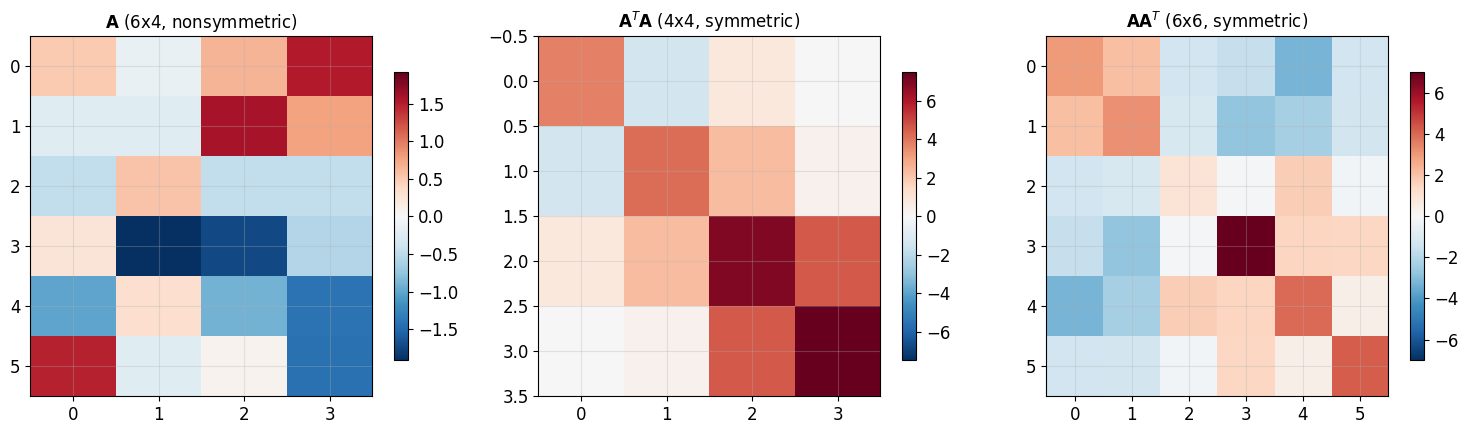

Figure saved.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

np.random.seed(42)
A = np.random.randn(6, 4)
AtA = A.T @ A
AAt = A @ A.T

for ax, M, title in zip(axes,
    [A, AtA, AAt],
    ['$\mathbf{A}$ (6x4, nonsymmetric)',
     '$\mathbf{A}^T\mathbf{A}$ (4x4, symmetric)',
     '$\mathbf{A}\mathbf{A}^T$ (6x6, symmetric)']):
    im = ax.imshow(M, cmap='RdBu_r', aspect='auto',
                   vmin=-np.max(np.abs(M)), vmax=np.max(np.abs(M)))
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig('fig_symmetric.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The visual symmetry is striking: the middle and right panels are **mirror images** across their main diagonals. Every colour above the diagonal has a matching colour below. The left panel (the original $\mathbf{A}$) has no such mirror structure -- it is rectangular and nonsymmetric.

**The punchline:** Start with any matrix -- random noise, a dataset, a transformation -- and multiplying it by its transpose produces a beautiful, structured, symmetric matrix. This is why covariance matrices and Gram matrices always have nice properties like real eigenvalues and orthogonal eigenvectors.

## Chapter Summary

This chapter introduced the fundamentals of matrices -- the second dimension of linear algebra. The key takeaways:

**Matrices as data structures.** A matrix $\mathbf{A} \in \mathbb{R}^{M \times N}$ is a grid of numbers that can represent datasets (rows $=$ observations, columns $=$ features), images (elements $=$ pixel values), or transformations.

**Special matrices.** Diagonal, triangular, identity ($\mathbf{I}$), zeros ($\mathbf{0}$), and symmetric matrices each have structural properties that enable efficient algorithms and stable computations.

**Element-wise operations.** Addition, subtraction, scalar multiplication, and Hadamard multiplication ($\odot$) all work entry by entry. **Shifting** ($\mathbf{A} + \lambda\mathbf{I}$) adds a scalar only to the diagonal and is the mechanism for eigenvalue computation and regularisation.

**Standard matrix multiplication** is a systematic collection of dot products: element $(i, j)$ of $\mathbf{C} = \mathbf{A}\mathbf{B}$ is the dot product of row $i$ of $\mathbf{A}$ with column $j$ of $\mathbf{B}$. The validity rule $M \times \boxed{N} \cdot \boxed{N} \times K = M \times K$ must be memorised. Multiplication is **not commutative**.

**Matrix-vector multiplication** implements linear weighted combinations compactly ($\mathbf{X}\boldsymbol{\beta}$ in regression) and geometric transformations (rotation + scaling). Vectors whose direction is preserved under multiplication are **eigenvectors** -- a preview of Chapter 13.

**Transpose** swaps rows and columns. The LIVE EVIL rule reverses the order: $(\mathbf{ABCD})^T = \mathbf{D}^T\mathbf{C}^T\mathbf{B}^T\mathbf{A}^T$. **Symmetric matrices** ($\mathbf{A} = \mathbf{A}^T$) can always be constructed via $\mathbf{A}^T\mathbf{A}$, and they underpin covariance, regression, and the SVD.